# 📗 บทที่ 8 — Ingest ทั้ง Vault: จากโฟลเดอร์โน้ต → second brain

**คู่กับ:** หนังสือบทที่ 8

บทก่อนใส่โน้ตทีละชิ้นด้วยมือ — ของจริงคือโฟลเดอร์ .md เป็นร้อยไฟล์
บทนี้สร้าง **ingest pipeline** จริง: อ่านไฟล์ → chunk → content-hash id → upsert แบบ idempotent


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip -q install chromadb sentence-transformers
import chromadb, hashlib, urllib.request, json
from pathlib import Path
import numpy as np
print('พร้อม ✓')


พร้อม ✓


In [2]:
# ---- ตัว embed อัจฉริยะ ----
def _ollama_ok():
    try:
        urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2); return True
    except Exception:
        return False

if _ollama_ok():
    def embed_texts(texts):
        req = urllib.request.Request('http://localhost:11434/api/embed',
            data=json.dumps({'model': 'bge-m3', 'input': list(texts)}).encode(),
            headers={'Content-Type': 'application/json'})
        with urllib.request.urlopen(req, timeout=180) as r:
            V = np.array(json.load(r)['embeddings'])
        return V / np.linalg.norm(V, axis=1, keepdims=True)
    print('embed: Ollama bge-m3 ✓')
else:
    from sentence_transformers import SentenceTransformer
    _m = SentenceTransformer('BAAI/bge-m3')
    def embed_texts(texts):
        return _m.encode(list(texts), normalize_embeddings=True)
    print('embed: sentence-transformers ✓')

from chromadb.utils.embedding_functions import EmbeddingFunction
class BgeM3(EmbeddingFunction):
    def __init__(self): pass
    def __call__(self, texts): return embed_texts(texts).tolist()


embed: Ollama bge-m3 ✓


## 1) สร้าง vault ตัวอย่าง (3 ไฟล์ .md) — ในงานจริงชี้ไปโฟลเดอร์โน้ตของคุณ


In [3]:
vault_dir = Path('./my_vault')
vault_dir.mkdir(exist_ok=True)

(vault_dir / 'research-embedding.md').write_text('''# งานวิจัย embedding หลายภาษา

bge-m3 รองรับ 100+ ภาษา ผ่านการเทรนแบบ contrastive
เหมาะกับ corpus ไทยปนอังกฤษ

## ผลทดลอง
GAP ของ bge-m3 = 0.393 กว้างสุดในสามโมเดลที่เทียบ''')

(vault_dir / 'workshop-plan.md').write_text('''# แผน workshop 26 กรกฎาคม

สอน vector search ให้นักวิจัย เริ่มจากเดโมก่อนค่อยลงสมการ

## อุปกรณ์
โน้ตบุ๊ก ติดตั้ง Python + Jupyter ล่วงหน้า''')

(vault_dir / 'coffee-notes.md').write_text('''# บันทึกกาแฟ

cold brew: กาแฟ 100g น้ำ 1L แช่ 18 ชั่วโมง
ratio ที่ชอบคือ 1:10''')

print('ไฟล์ใน vault:', [f.name for f in sorted(vault_dir.glob('*.md'))])


ไฟล์ใน vault: ['coffee-notes.md', 'research-embedding.md', 'workshop-plan.md']


## 2) Chunking: แตกไฟล์เป็นชิ้นตามหัวข้อ (## boundary)

chunk เล็ก = embed แม่น (บทที่ 4) · ใช้โครงสร้าง markdown เป็นรอยตัดธรรมชาติ


In [4]:
def chunk_markdown(text, source):
    chunks, cur, heading = [], [], ''
    for line in text.split('\n'):
        if line.startswith('#'):
            if cur and ''.join(cur).strip():
                chunks.append({'text': '\n'.join(cur).strip(), 'heading': heading, 'source': source})
            heading, cur = line.lstrip('# ').strip(), [line]
        else:
            cur.append(line)
    if cur and ''.join(cur).strip():
        chunks.append({'text': '\n'.join(cur).strip(), 'heading': heading, 'source': source})
    return chunks

all_chunks = []
for f in sorted(vault_dir.glob('*.md')):
    all_chunks += chunk_markdown(f.read_text(), f.name)
for c in all_chunks:
    print(f"[{c['source']}] {c['heading']:<28} {len(c['text'])} chars")


[coffee-notes.md] บันทึกกาแฟ                   77 chars
[research-embedding.md] งานวิจัย embedding หลายภาษา  109 chars
[research-embedding.md] ผลทดลอง                      60 chars
[workshop-plan.md] แผน workshop 26 กรกฎาคม      84 chars
[workshop-plan.md] อุปกรณ์                      53 chars


## 3) ⭐ Content-hash id — หัวใจของ idempotency

id = hash ของเนื้อหา (เหมือน git): เนื้อหาเดิม → id เดิม → รัน ingest ซ้ำกี่ครั้งก็ไม่ duplicate


In [5]:
def chunk_id(c):
    return hashlib.sha256(f"{c['source']}|{c['heading']}|{c['text']}".encode()).hexdigest()[:16]

client = chromadb.PersistentClient(path='./chroma_db')
try:
    client.delete_collection('my_vault')
except Exception:
    pass
col = client.create_collection('my_vault', embedding_function=BgeM3(), metadata={'hnsw:space':'cosine'})

def ingest(chunks):
    existing = set(col.get()['ids'])
    new = [c for c in chunks if chunk_id(c) not in existing]
    if new:
        col.upsert(ids=[chunk_id(c) for c in new],
                   documents=[c['text'] for c in new],
                   metadatas=[{'source': c['source'], 'heading': c['heading']} for c in new])
    return len(new), len(chunks) - len(new)

added, skipped = ingest(all_chunks)
print(f'รอบ 1: เพิ่ม {added} · ข้าม {skipped} · รวมใน DB {col.count()}')
added2, skipped2 = ingest(all_chunks)
print(f'รอบ 2 (รันซ้ำ): เพิ่ม {added2} · ข้าม {skipped2} — idempotent! ไม่ embed ซ้ำ ไม่ duplicate')


รอบ 1: เพิ่ม 5 · ข้าม 0 · รวมใน DB 5
รอบ 2 (รันซ้ำ): เพิ่ม 0 · ข้าม 5 — idempotent! ไม่ embed ซ้ำ ไม่ duplicate


## 4) ค้นข้าม vault พร้อม provenance (มาจากไฟล์ไหน หัวข้ออะไร)


In [6]:
for q in ['โมเดลไหนเหมาะกับภาษาไทย', 'ต้องเตรียมอะไรไปสอน']:
    res = col.query(query_texts=[q], n_results=2)
    print(f'Q: {q}')
    for doc, meta in zip(res['documents'][0], res['metadatas'][0]):
        print(f"   📄 {meta['source']} → {meta['heading']}")
        print(f"      {doc[:60]}...")
    print()


Q: โมเดลไหนเหมาะกับภาษาไทย
   📄 research-embedding.md → งานวิจัย embedding หลายภาษา
      # งานวิจัย embedding หลายภาษา

bge-m3 รองรับ 100+ ภาษา ผ่านก...
   📄 workshop-plan.md → อุปกรณ์
      ## อุปกรณ์
โน้ตบุ๊ก ติดตั้ง Python + Jupyter ล่วงหน้า...



Q: ต้องเตรียมอะไรไปสอน
   📄 workshop-plan.md → อุปกรณ์
      ## อุปกรณ์
โน้ตบุ๊ก ติดตั้ง Python + Jupyter ล่วงหน้า...
   📄 workshop-plan.md → แผน workshop 26 กรกฎาคม
      # แผน workshop 26 กรกฎาคม

สอน vector search ให้นักวิจัย เริ...



## 5) แก้ไฟล์ → ingest ใหม่ → embed เฉพาะส่วนที่เปลี่ยน


In [7]:
# เพิ่ม section ใหม่เข้าไฟล์เดิม
f = vault_dir / 'coffee-notes.md'
f.write_text(f.read_text() + '''

## มอคค่าพอท
ไฟกลาง 4 นาที ได้ช็อตเข้มกำลังดี''')

all_chunks = []
for fp in sorted(vault_dir.glob('*.md')):
    all_chunks += chunk_markdown(fp.read_text(), fp.name)
added3, skipped3 = ingest(all_chunks)
print(f'หลังแก้ไฟล์: เพิ่ม {added3} chunk ใหม่ · ข้าม {skipped3} chunk เดิม (ไม่ embed ซ้ำ = ประหยัด)')


หลังแก้ไฟล์: เพิ่ม 1 chunk ใหม่ · ข้าม 5 chunk เดิม (ไม่ embed ซ้ำ = ประหยัด)


## ✅ วัดผลตัวเอง #8


In [8]:
assert added2 == 0, 'รันซ้ำต้องไม่เพิ่มอะไรเลย (idempotent)'
assert added3 >= 1 and skipped3 >= 5, 'แก้ไฟล์ต้อง embed เฉพาะส่วนใหม่'
res = col.query(query_texts=['วิธีชงกาแฟเข้มๆ'], n_results=1)
assert res['metadatas'][0][0]['source'] == 'coffee-notes.md', 'section ใหม่ต้องค้นเจอทันที'
print('✅ ผ่าน! pipeline ครบ: chunk → hash id → idempotent ingest → ค้นเจอของใหม่ทันที (freshness)')


✅ ผ่าน! pipeline ครบ: chunk → hash id → idempotent ingest → ค้นเจอของใหม่ทันที (freshness)


## 📊 เห็นภาพ — idempotent ingest (รันซ้ำไม่ embed ซ้ำ)


/var/folders/lf/s98q6y892sl__0brv1tyn0ch0000gn/T/ipykernel_32348/417439628.py:15: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  plt.title('บทที่ 8 — รันซ้ำ→เพิ่ม 0 · แก้ไฟล์→เพิ่มเฉพาะที่เปลี่ยน'); plt.tight_layout(); plt.show()
/opt/Code/github.com/laris-co/ajfon-oracle/book/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


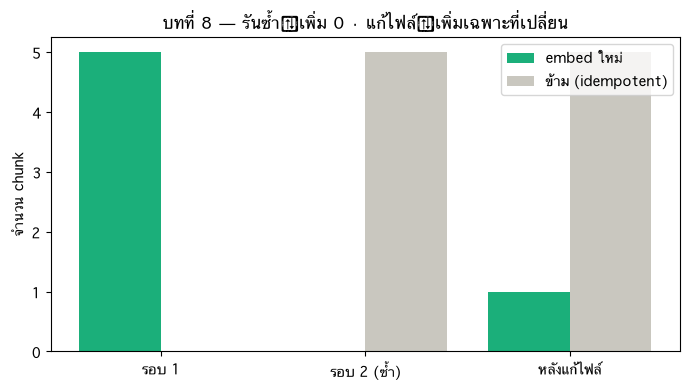

In [9]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_av={f.name for f in _fm.fontManager.ttflist}
for _f in ['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
import numpy as np
rounds=['รอบ 1','รอบ 2 (ซ้ำ)','หลังแก้ไฟล์']
add=[added,added2,added3]; skip=[skipped,skipped2,skipped3]
x=np.arange(3); w=0.4; plt.figure(figsize=(7,4))
plt.bar(x-w/2,add,w,label='embed ใหม่',color='#1baf7a')
plt.bar(x+w/2,skip,w,label='ข้าม (idempotent)',color='#c9c7bf')
plt.xticks(x,rounds); plt.ylabel('จำนวน chunk'); plt.legend()
plt.title('บทที่ 8 — รันซ้ำ→เพิ่ม 0 · แก้ไฟล์→เพิ่มเฉพาะที่เปลี่ยน'); plt.tight_layout(); plt.show()


## 🏋️ แบบฝึก
1. ชี้ `vault_dir` ไปโฟลเดอร์โน้ตจริงของคุณ (ระวัง: ไฟล์เยอะ = embed นาน — เริ่มจากโฟลเดอร์เล็ก)
2. ลบ section หนึ่งจากไฟล์ — chunk เก่ายังอยู่ใน DB ไหม? ควรทำยังไง? (เฉลย: tombstone, ดู deep-technical Ch45)

**บทต่อไป:** `ch09_rag_cite.ipynb` — ต่อ LLM ให้ตอบจากโน้ตเรา พร้อมอ้างอิง
